In [2]:
# Basic imports
import os, sys
sys.path.insert(0, os.path.abspath('..')) # This to add the Soprano path to the PYTHONPATH
                                          # so we can load it without installing it

In [3]:
# Other useful imports

import numpy as np

import ase
from ase import io as ase_io

%matplotlib inline
import matplotlib.pyplot as plt
plt.ion()

%reload_ext autoreload
%autoreload 2

In [4]:
HQ = ase_io.read('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/CASTEP/8-HQ-ipc2-B_opt_magres_updated.magres')
HQ_J = ase_io.read('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/CASTEP/8-HQ-ipc2-B_opt_magres_J.magres')
B_static = np.loadtxt('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/SW_Shiva6.txt')


In [5]:
labels = HQ.get_array('labels')
indices = HQ.get_array('indices')
B_i = np.where(labels == 'B')
B = HQ[B_i]

print('There are {0} boron atoms'.format(len(B)))


There are 1 boron atoms


In [6]:
# One can also recreate the Jmol/MagresView-style labels if needed:
jmol_labels = ["{0}_{1}".format(l, i) for l, i in zip(labels, indices)]

print("The labels are {0}".format(', '.join(jmol_labels)))

The labels are H_1, H_2, H_3, H_4, H_5, H_6, H_7, H_8, H_9, H_10, H_11, H_12, H_13, H_14, H_15, H_16, H_17, H_18, H_19, H_20, H_21, H_22, H_23, H_24, H_25, H_26, H_27, H_28, H_29, H_30, H_31, H_32, H_33, H_34, H_35, H_36, H_37, H_38, H_39, H_40, H_41, H_42, H_43, H_44, H_45, H_46, H_47, H_48, H_49, H_50, H_51, H_52, H_53, H_54, H_55, H_56, H_57, H_58, H_59, H_60, H_61, H_62, H_63, H_64, H_65, H_66, H_67, H_68, H_69, H_70, H_71, H_72, H_73, H_74, H_75, H_76, H_77, H_78, H_79, H_80, H_81, H_82, H_83, H_84, H_85, H_86, H_87, H_88, H_89, H_90, H_91, H_92, H_93, H_94, H_95, H_96, H_97, H_98, H_99, H_100, H_101, H_102, H_103, H_104, H_105, H_106, H_107, H_108, H_109, H_110, H_111, H_112, H_113, H_114, H_115, H_116, H_117, H_118, H_119, H_120, H_121, H_122, H_123, H_124, H_125, H_126, H_127, H_128, H_129, H_130, H_131, H_132, H_133, H_134, H_135, H_136, H_137, H_138, H_139, H_140, H_141, H_142, H_143, H_144, H_145, H_146, H_147, H_148, H_149, H_150, H_151, H_152, H_153, H_154, H_155, H_156, H

In [7]:
from soprano.properties.nmr import *

# Isotropy, Anisotropy and Asymmetry (Haeberlen convention)
# These return arrays of the same length as the number of atoms.
iso = MSIsotropy.get(HQ)
aniso = MSAnisotropy.get(HQ)
asymm = MSAsymmetry.get(HQ)

print('Label\tIsotropy\tAnisotropy\tAsymmetry')
for i, jl in enumerate(jmol_labels):
    print('{0}\t{1:6.2f} ppm\t{2:6.2f} ppm\t{3:3.2f}'.format(jl, iso[i], aniso[i], asymm[i]))

Label	Isotropy	Anisotropy	Asymmetry
H_1	 22.91 ppm	 11.10 ppm	0.57
H_2	 22.91 ppm	 11.10 ppm	0.57
H_3	 22.91 ppm	 11.10 ppm	0.57
H_4	 22.91 ppm	 11.10 ppm	0.57
H_5	 24.04 ppm	 -7.14 ppm	0.88
H_6	 24.04 ppm	 -7.14 ppm	0.88
H_7	 24.04 ppm	 -7.14 ppm	0.88
H_8	 24.04 ppm	 -7.14 ppm	0.88
H_9	 22.67 ppm	  3.63 ppm	0.34
H_10	 22.67 ppm	  3.63 ppm	0.34
H_11	 22.67 ppm	  3.63 ppm	0.34
H_12	 22.67 ppm	  3.63 ppm	0.34
H_13	 23.09 ppm	  3.16 ppm	0.89
H_14	 23.09 ppm	  3.16 ppm	0.89
H_15	 23.09 ppm	  3.16 ppm	0.89
H_16	 23.09 ppm	  3.16 ppm	0.89
H_17	 22.48 ppm	 -3.35 ppm	0.44
H_18	 22.48 ppm	 -3.35 ppm	0.44
H_19	 22.48 ppm	 -3.35 ppm	0.44
H_20	 22.48 ppm	 -3.35 ppm	0.44
H_21	 22.98 ppm	 -1.91 ppm	0.86
H_22	 22.98 ppm	 -1.91 ppm	0.86
H_23	 22.98 ppm	 -1.91 ppm	0.86
H_24	 22.98 ppm	 -1.91 ppm	0.86
H_25	 29.98 ppm	 -7.82 ppm	0.88
H_26	 29.98 ppm	 -7.82 ppm	0.88
H_27	 29.98 ppm	 -7.82 ppm	0.88
H_28	 29.98 ppm	 -7.82 ppm	0.88
H_29	 31.59 ppm	 13.96 ppm	0.14
H_30	 31.59 ppm	 13.96 ppm	0.14
H_31	 31.59 p

**J Couplings**

In [8]:
from soprano.properties.nmr import JCIsotropy
jcoupling = JCIsotropy().get(
        HQ_J,                 # the crystal structure (ASE Atoms object)
        isotopes = {'B': 11},   # You can specify whatever isotopes you want here.
        tag = 'isc',           # Which J coupling component to use. 'isc' is default. See your magres file for what has been computed.  
        self_coupling = False, # include interactions with periodic images of self?
        )
        
# Now we print out the couplings
print('i\tj\tJ coupling/Hz')
for (i,j), jcoup in jcoupling.items():
    # We can filter out the couplings to just the largest ones e.g.
    # to only print out the couplings larger than 5 Hz:
    if np.abs(jcoup) > 5: 
         print(f"{jmol_labels[i]}\t{jmol_labels[j]}\t{jcoup:10.2f}")

i	j	J coupling/Hz
B_1	N_1	      5.86
C_1	N_1	      5.03


**Static Line Shape Simulation**

In [9]:
from soprano.calculate.nmr.nmr import NMRCalculator, NMRFlags

nCalc = NMRCalculator(HQ) # We create the calculator here

# Setting the Larmor frequency; default units are MHz
# This is set for a specific isotope and determines the magnetic field for everything else as well
nCalc.set_larmor_frequency(600, element='1H')
print("Field: {0:.2f} T".format(nCalc.B))
# We can also get what the frequency would be for a different element...
print("Larmor frequency for 11B: {0:.2f} MHz".format(nCalc.get_larmor_frequency('11B')))

# Set a reference shielding, in ppm
nCalc.set_reference(20.5, '11B')

# Set a powder averaging. Higher values of N mean finer average
nCalc.set_powder(N=16)
print("Powder orientations: {0}".format(len(nCalc._orients[0])))

Field: 14.09 T
Larmor frequency for 11B: 192.54 MHz
Powder orientations: 545


In [10]:
# Now let's look at the static quadrupolar line of 11B
freqRange = 1000000
spec11B_1, freqs = nCalc.spectrum_1d('11B', effects=NMRFlags.Q_1_ORIENT, max_freq=freqRange, min_freq=-freqRange, bins=501)
spec11B_s, freqs = nCalc.spectrum_1d('11B', effects=NMRFlags.Q_STATIC, max_freq=freqRange, min_freq=-freqRange, bins=501)

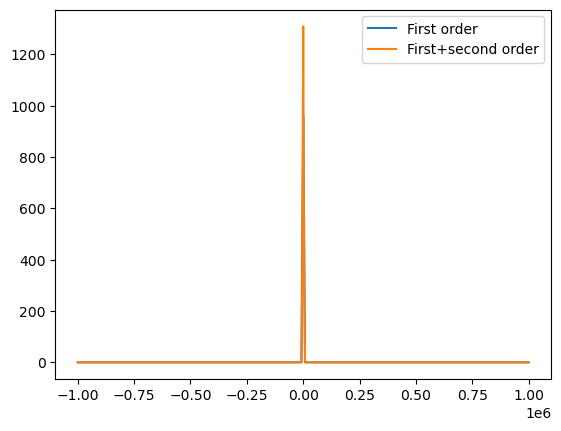

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(freqs, spec11B_1, label='First order')
ax.plot(freqs, spec11B_s, label='First+second order')

ax.legend()

In [12]:
yData = B_static / max(B_static)  # Normalize
yData = B_static - min(B_static)  # Remove vertical offset
steps = len(yData)
x_start = 109.4                               #value from data file
x_end = -150.3                                #value from data file
steps_ppm = (x_end - x_start)/steps
x = np.arange(x_start, x_end, steps_ppm)

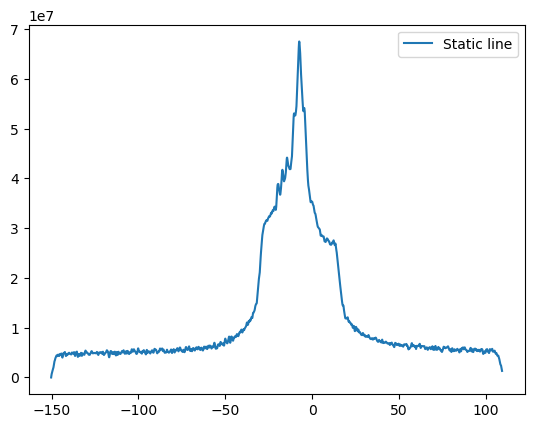

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x, yData, label='Static line')
ax.legend()



In [19]:
ms_tensors = MSTensor.get(
                         HQ,
                        
                          )
efg_tensors = EFGTensor.get(
                            HQ,
                            
                            )

print('Euler angles from the MS to EFG tensors for each atom:')
print("α\t\tβ\t\tγ (deg)")
for ms, efg in zip(ms_tensors, efg_tensors):
    eulers = ms.euler_to(efg)
    print('{0:6.2f}\t\t {1:6.2f}\t\t {2:6.2f}'.format(*eulers* 180 / np.pi))

Euler angles from the MS to EFG tensors for each atom:
α		β		γ (deg)
 13.73		  63.56		  95.38
166.27		  63.56		  84.62
 13.73		  63.56		  95.38
166.27		  63.56		  84.62
173.78		  45.22		 122.13
  6.22		  45.22		  57.87
173.78		  45.22		 122.13
  6.22		  45.22		  57.87
160.55		  85.30		  10.72
 19.45		  85.30		 169.28
160.55		  85.30		  10.72
 19.45		  85.30		 169.28
316.56		  25.63		 123.00
223.44		  25.63		  57.00
316.56		  25.63		 123.00
223.44		  25.63		  57.00
188.01		  82.51		  97.34
351.99		  82.51		  82.66
188.01		  82.51		  97.34
351.99		  82.51		  82.66
205.95		  12.88		  91.55
334.05		  12.88		  88.45
205.95		  12.88		  91.55
334.05		  12.88		  88.45
142.34		  45.53		  96.26
217.66		  45.53		  83.74
142.34		  45.53		  96.26
217.66		  45.53		  83.74
330.83		  26.37		 111.01
209.17		  26.37		  68.99
330.83		  26.37		 111.01
209.17		  26.37		  68.99
  3.88		  33.73		  94.82
356.12		  33.73		  85.18
  3.88		  33.73		  94.82
356.12		  33.73		  85.18
 69.69		  20.03		  85.85
290.31